In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
# Base path to our dataset
BASE_PATH = "data/raw/PlantVillage"

# Our 6 selected classes
CLASSES = {
    "Tomato_Early_blight": "Tomato Early Blight",
    "Tomato_healthy": "Tomato Healthy",
    "Pepper__bell___Bacterial_spot": "Pepper Bacterial Spot",
    "Pepper__bell___healthy": "Pepper Healthy",
    "Potato___Early_blight": "Potato Early Blight",
    "Potato___healthy": "Potato Healthy"
}

# Verify all folders exist
print("Checking class folders...")
for folder, label in CLASSES.items():
    path = os.path.join(BASE_PATH, folder)
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"✓ {label}: {count} images found")
    else:
        print(f"✗ {label}: FOLDER NOT FOUND")

Checking class folders...
✗ Tomato Early Blight: FOLDER NOT FOUND
✗ Tomato Healthy: FOLDER NOT FOUND
✗ Pepper Bacterial Spot: FOLDER NOT FOUND
✗ Pepper Healthy: FOLDER NOT FOUND
✗ Potato Early Blight: FOLDER NOT FOUND
✗ Potato Healthy: FOLDER NOT FOUND


In [ ]:
# Let's find the correct path
import os

# Check what's inside data/raw
print("Contents of data/raw:")
for item in os.listdir("data/raw"):
    print(f"  {item}")

print("\nContents of data/raw/PlantVillage:")
for item in os.listdir("data/raw/PlantVillage"):
    print(f"  {item}")

Contents of data/raw:


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw'

In [4]:
import os
print(os.getcwd())


C:\Users\Hp\farmguard-ai\notebooks


In [5]:
import os

# Move up one level to the project root
os.chdir("..")

# Verify we're now in the right place
print("Current directory:", os.getcwd())

# Check contents
print("\nContents:")
for item in os.listdir("."):
    print(f"  {item}")

Current directory: C:\Users\Hp\farmguard-ai

Contents:
  .vscode
  api
  dashboard
  data
  docker-compose.yml
  Dockerfile
  models
  notebooks
  README.md
  requirements.txt
  src
  tests
  venv


In [6]:
# Base path to our dataset
BASE_PATH = "data/raw/PlantVillage"

# Our 6 selected classes
CLASSES = {
    "Tomato_Early_blight": "Tomato Early Blight",
    "Tomato_healthy": "Tomato Healthy",
    "Pepper__bell___Bacterial_spot": "Pepper Bacterial Spot",
    "Pepper__bell___healthy": "Pepper Healthy",
    "Potato___Early_blight": "Potato Early Blight",
    "Potato___healthy": "Potato Healthy"
}

# Verify all folders exist
print("Checking class folders...")
for folder, label in CLASSES.items():
    path = os.path.join(BASE_PATH, folder)
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"✓ {label}: {count} images found")
    else:
        print(f"✗ {label}: FOLDER NOT FOUND")

Checking class folders...
✓ Tomato Early Blight: 1000 images found
✓ Tomato Healthy: 1591 images found
✓ Pepper Bacterial Spot: 997 images found
✓ Pepper Healthy: 1478 images found
✓ Potato Early Blight: 1000 images found
✓ Potato Healthy: 152 images found


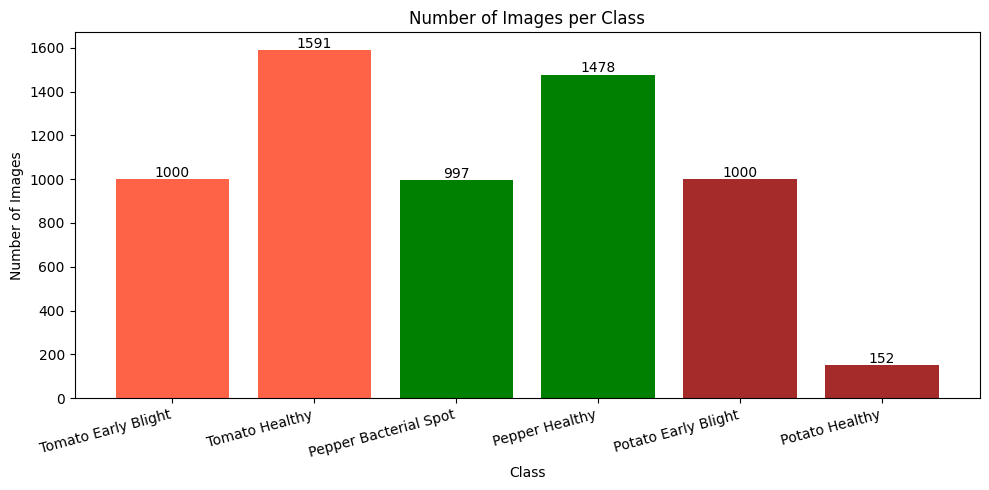

In [7]:
# Visualise image count per class
class_names = list(CLASSES.values())
image_counts = []

for folder in CLASSES.keys():
    path = os.path.join(BASE_PATH, folder)
    image_counts.append(len(os.listdir(path)))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, image_counts, color=['tomato','tomato','green','green','brown','brown'])
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15, ha='right')
for bar, count in zip(bars, image_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

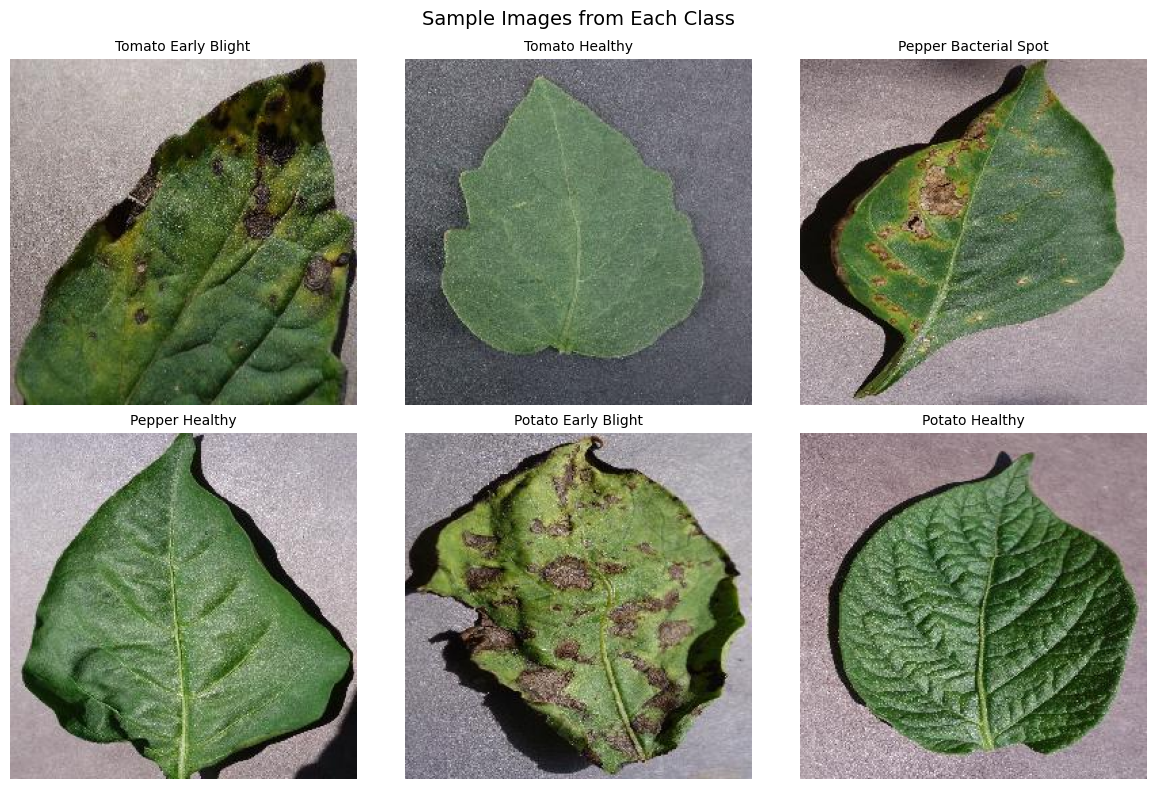

In [8]:
# Display sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (folder, label) in enumerate(CLASSES.items()):
    path = os.path.join(BASE_PATH, folder)
    images = os.listdir(path)
    sample_image_path = os.path.join(path, images[0])
    img = Image.open(sample_image_path)
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=10)
    axes[idx].axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

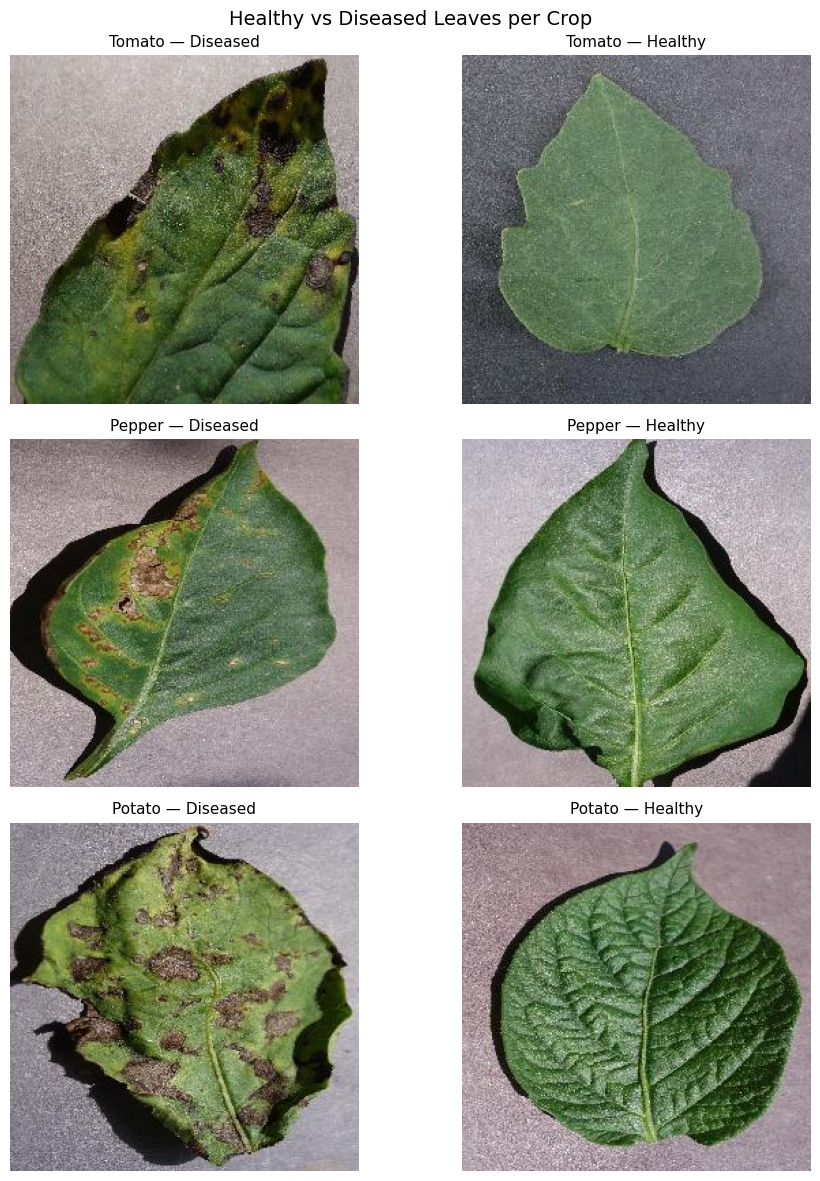

In [9]:
# Display healthy vs diseased for each crop
crops = {
    "Tomato": {
        "Diseased": "Tomato_Early_blight",
        "Healthy": "Tomato_healthy"
    },
    "Pepper": {
        "Diseased": "Pepper__bell___Bacterial_spot",
        "Healthy": "Pepper__bell___healthy"
    },
    "Potato": {
        "Diseased": "Potato___Early_blight",
        "Healthy": "Potato___healthy"
    }
}

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row_idx, (crop, variants) in enumerate(crops.items()):
    for col_idx, (condition, folder) in enumerate(variants.items()):
        path = os.path.join(BASE_PATH, folder)
        images = os.listdir(path)
        sample = os.path.join(path, images[0])
        img = Image.open(sample)
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].set_title(f"{crop} — {condition}", fontsize=11)
        axes[row_idx][col_idx].axis('off')

plt.suptitle("Healthy vs Diseased Leaves per Crop", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Check image sizes and formats across all classes
print("Checking image properties...\n")

for folder, label in CLASSES.items():
    path = os.path.join(BASE_PATH, folder)
    images = os.listdir(path)
    
    # Check first 5 images in each class
    sizes = []
    formats = []
    for img_name in images[:5]:
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)
        formats.append(img.format)
    
    print(f"{label}:")
    print(f"  Sizes found: {set(sizes)}")
    print(f"  Formats found: {set(formats)}")
    print()

Checking image properties...

Tomato Early Blight:
  Sizes found: {(256, 256)}
  Formats found: {'JPEG'}

Tomato Healthy:
  Sizes found: {(256, 256)}
  Formats found: {'JPEG'}

Pepper Bacterial Spot:
  Sizes found: {(256, 256)}
  Formats found: {'JPEG'}

Pepper Healthy:
  Sizes found: {(256, 256)}
  Formats found: {'JPEG'}

Potato Early Blight:
  Sizes found: {(256, 256)}
  Formats found: {'JPEG'}

Potato Healthy:
  Sizes found: {(256, 256)}
  Formats found: {'JPEG'}



In [13]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Output directories
SPLIT_DIR = "data/split"
SPLITS = ["train", "val", "test"]

# Create split folders
for split in SPLITS:
    for folder in CLASSES.keys():
        os.makedirs(os.path.join(SPLIT_DIR, split, folder), exist_ok=True)

print("Splitting dataset into train / val / test...\n")

for folder, label in CLASSES.items():
    src_path = os.path.join(BASE_PATH, folder)
    images = os.listdir(src_path)
    
    # Split: 70% train, 15% val, 15% test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)
    
    # Copy images into split folders
    for img in train_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(SPLIT_DIR, "train", folder, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(SPLIT_DIR, "val", folder, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_path, img), os.path.join(SPLIT_DIR, "test", folder, img))
    
    print(f"{label}:")
    print(f"  Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

print("\nDataset split complete!")

Splitting dataset into train / val / test...

Tomato Early Blight:
  Train: 700 | Val: 150 | Test: 150
Tomato Healthy:
  Train: 1113 | Val: 239 | Test: 239
Pepper Bacterial Spot:
  Train: 697 | Val: 150 | Test: 150
Pepper Healthy:
  Train: 1034 | Val: 222 | Test: 222
Potato Early Blight:
  Train: 700 | Val: 150 | Test: 150
Potato Healthy:
  Train: 106 | Val: 23 | Test: 23

Dataset split complete!


In [14]:
# Verify split folders
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} SET:")
    for folder in CLASSES.keys():
        path = os.path.join(SPLIT_DIR, split, folder)
        count = len(os.listdir(path))
        print(f"  {folder}: {count} images")


TRAIN SET:
  Tomato_Early_blight: 700 images
  Tomato_healthy: 1113 images
  Pepper__bell___Bacterial_spot: 697 images
  Pepper__bell___healthy: 1034 images
  Potato___Early_blight: 700 images
  Potato___healthy: 106 images

VAL SET:
  Tomato_Early_blight: 150 images
  Tomato_healthy: 239 images
  Pepper__bell___Bacterial_spot: 150 images
  Pepper__bell___healthy: 222 images
  Potato___Early_blight: 150 images
  Potato___healthy: 23 images

TEST SET:
  Tomato_Early_blight: 150 images
  Tomato_healthy: 239 images
  Pepper__bell___Bacterial_spot: 150 images
  Pepper__bell___healthy: 222 images
  Potato___Early_blight: 150 images
  Potato___healthy: 23 images


In [15]:
# Save class names and paths for use in training
print("CLASS CONFIGURATION FOR TRAINING")
print("="*40)
print(f"Number of classes: {len(CLASSES)}")
print(f"Split directory: {SPLIT_DIR}")
print(f"Image size for CNN: 224x224")
print(f"\nClass names:")
for idx, (folder, label) in enumerate(CLASSES.items()):
    print(f"  {idx}: {label}")
print("\nData exploration complete! Ready for Phase 3.")

CLASS CONFIGURATION FOR TRAINING
Number of classes: 6
Split directory: data/split
Image size for CNN: 224x224

Class names:
  0: Tomato Early Blight
  1: Tomato Healthy
  2: Pepper Bacterial Spot
  3: Pepper Healthy
  4: Potato Early Blight
  5: Potato Healthy

Data exploration complete! Ready for Phase 3.
